# Where TPs sit relative to FPs, in score -- at `z = 1.0` and beyond

**Purpose.** `tm_threshold_axis_sweep_v2.ipynb` fixed the border and NMS-radius leaks and
settled on `z = 1.0` as the operating floor (full recall in every domain at that level). The
candidate list at `z = 1.0` is still large -- tens of thousands per domain, almost all
`non_human_findings` (unannotated FP). This notebook doesn't change the pipeline again; it
visualizes *why*: every candidate's `TM_CCOEFF` score (in per-map robust `z` units, the same
`z` the floor is defined in), split by whether it is a true positive, a look-alike FP, or an
unannotated FP, so it's visible where TPs sit relative to the FP crowd -- both to confirm
`z=1.0` isn't cutting any of them (it isn't, per the sweep) and to see whether there is any
headroom to push the floor higher without starting to cut them.

**What's plotted, and why this form.** Every true positive is plotted (there are only
17-238 per domain -- never worth subsampling). `human_rejected_label` (look-alike FP) is
small enough in every domain (49-123) to plot in full too. `non_human_findings` (unannotated
FP) is 18,600-29,600 per domain; those *are* subsampled for rendering (fixed seed, capped
per domain, exact fraction printed) -- per the brief, dense is fine to subsample, everything
else is plotted whole. FP points are rendered translucent so their density still reads
through overlap; TPs are opaque and on top so they are never hidden under the FP crowd.

**Verification, not re-assumption.** This notebook re-derives its own deep candidate pool
with the exact `tm_threshold_axis_sweep_v2.ipynb` pipeline (same padding, same decoupled NMS
radius, same seed rule) rather than trusting a copy-paste, and then cross-checks the result
against that notebook's saved CSV at every `z` level before trusting the plot built on top of
it -- see the "check the work" section below.

In [1]:
import time
NB_T0 = time.time()

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from midog_utils import channels as ch
from midog_utils import dataset as ds
from midog_utils import evaluate as ev
from midog_utils import experiment as ex
from midog_utils import find_and_suppress as fs
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm
from midog_utils.nms import nms_by_distance

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
print('imports ok')

imports ok


## Configuration -- identical to `tm_threshold_axis_sweep_v2.ipynb`

Same channel, method, template size, seed rule, `DEEP_FLOOR_Z`, `NMS_RADIUS_UM` and
`MATCH_RADIUS_UM` as the notebook that decided on `z=1.0`. `CURRENT_Z` is updated to `1.0`
(the decision from that conversation) -- everything else is copied, not re-derived, so this
notebook's deep pool is provably the same pool that decision was made from.

In [2]:
CHANNEL = 'hematoxylin_od'
METHOD = cv2.TM_CCOEFF
BASE_SIZE = tm.BASE_SIZE
PEAK_MIN_DISTANCE = 7
SEED_INDEX = 0
SELF_HIT_RADIUS = 5.0

DEEP_FLOOR_Z = -1.5
CURRENT_Z = 1.0                                        # the operating point just decided on
NMS_RADIUS_UM = 5.0
MATCH_RADIUS_UM = ev.MIDOG_RADIUS_UM
MAX_PEAKS = 2_000_000

FP_SUBSAMPLE_CAP = 8000                                 # per domain, non_human_findings only
RNG_SEED = 0

CFG = fs.FSConfig(channel=CHANNEL, base_size=BASE_SIZE, scales=(1.0,),
                  n_angles=1, flips=(False,), peak_min_distance=PEAK_MIN_DISTANCE,
                  self_hit_radius=SELF_HIT_RADIUS)
BORDER = CFG.patch_size // 2

BUCKET_COLOR = {ev.HUMAN_CORRECT_LABEL: '#2ca02c',
               ev.HUMAN_REJECTED_LABEL: '#ff7f0e',
               ev.NON_HUMAN_FINDINGS: '#7f7f7f'}
BUCKET_LABEL = {ev.HUMAN_CORRECT_LABEL: 'TP (mitotic)',
               ev.HUMAN_REJECTED_LABEL: 'FP -- look-alike',
               ev.NON_HUMAN_FINDINGS: 'FP -- unannotated'}
BUCKET_LANE = {ev.HUMAN_CORRECT_LABEL: 2, ev.HUMAN_REJECTED_LABEL: 1, ev.NON_HUMAN_FINDINGS: 0}

## One ROI per domain -- same selection as before

In [3]:
images, annotations = ds.load_annotations()
ds.check_invariants(annotations)
domain_images = ex.select_domain_images(images, annotations, images_dir='images')
domain_images = domain_images.sort_values('tumor_type').reset_index(drop=True)
domain_images[['tumor_type', 'file_name', 'image_id', 'n_mitotic']]

,tumor_type,file_name,image_id,n_mitotic
0,canine cutaneous mast cell tumor,301.tiff,301,218
1,canine lung cancer,201.tiff,201,18
2,canine lymphosarcoma,246.tiff,246,116
3,canine soft tissue sarcoma,459.tiff,459,131
4,human breast cancer,094.tiff,94,82
5,human melanoma,548.tiff,548,239
6,human neuroendocrine tumor,402.tiff,402,105


## Rebuild the deep pool, bucket every candidate against ground truth

Padding, matching, cropping, extraction, NMS at the decoupled radius, self-hit removal --
byte-for-byte the same steps as `tm_threshold_axis_sweep_v2.ipynb`'s main loop. The one new
step is `evaluate.bucket_detections`, called directly here (rather than through
`compare.evaluate_arms`) so every candidate keeps its own `bucket` label instead of only the
aggregate counts the sweep notebook saved.

In [4]:
pools = {}
bucket_counts = {}

for _, row in domain_images.iterrows():
    fn, image_id, domain = row['file_name'], int(row['image_id']), row['tumor_type']
    t0 = time.time()

    rgb = ds.load_roi(f'images/{fn}')
    mpp = ds.roi_mpp(f'images/{fn}')
    match_radius = ev.radius_px(mpp, MATCH_RADIUS_UM)
    nms_radius = ev.radius_px(mpp, NMS_RADIUS_UM)
    hem = ch.to_channel(rgb, CHANNEL)
    H, W = hem.shape[:2]
    gt = ds.image_annotations(annotations, fn)
    gt_mit = gt[gt['category_id'] == ds.MITOTIC]

    pool_seed, flagged = ss.agreement_pool(gt_mit)
    pool_seed = ss.border_filter(pool_seed, BORDER, rgb.shape)
    rng = np.random.default_rng([SEED_INDEX, image_id])
    seed = pool_seed.iloc[int(rng.integers(len(pool_seed)))]
    seed_xy = (float(seed['cx']), float(seed['cy']))
    gt_eval = gt[gt['ann_id'] != int(seed['ann_id'])].reset_index(drop=True)

    patch = tm.read_padded_patch(hem, *seed_xy, CFG.patch_size)
    templates, _ = tm.build_augmentations(patch, CFG.base_size, CFG.scales,
                                          CFG.n_angles, CFG.flips)

    PAD = max((t.shape[0] - 1) // 2 for t in templates)
    hem_p = cv2.copyMakeBorder(hem, PAD, PAD, PAD, PAD, borderType=cv2.BORDER_REPLICATE)
    fused_p, best_p, valid_p = tm.fused_response(hem_p, templates, CFG.scale_normalize, method=METHOD)
    fused = fused_p[PAD:PAD + H, PAD:PAD + W]
    valid = valid_p[PAD:PAD + H, PAD:PAD + W]
    assert bool(valid.all()), f'{fn}: padding did not make the whole ROI valid'

    med, mad = tm.robust_stats(fused, valid)
    deep_floor = med + DEEP_FLOOR_Z * mad
    centers, scores = tm.extract_peaks(fused, valid, PEAK_MIN_DISTANCE, deep_floor, MAX_PEAKS)

    keep = nms_by_distance(centers, scores, nms_radius)
    centers, scores = centers[keep], scores[keep]
    ok = np.hypot(centers[:, 0] - seed_xy[0], centers[:, 1] - seed_xy[1]) > CFG.self_hit_radius
    centers, scores = centers[ok], scores[ok]

    pool = pd.DataFrame({'cx': centers[:, 0], 'cy': centers[:, 1], 'score': scores})
    pool['z'] = (pool['score'] - med) / mad
    pool = pool.sort_values('score', ascending=False).reset_index(drop=True)

    det_out, gt_out = ev.bucket_detections(pool, gt_eval, match_radius)
    det_out['tumor_type'] = domain
    det_out['file_name'] = fn
    det_out['n_gt_mitotic'] = int((gt_eval['category_id'] == ds.MITOTIC).sum())
    det_out['map_median'] = med
    det_out['mad_scale'] = mad

    pools[fn] = det_out
    vc = det_out['bucket'].value_counts().to_dict()
    bucket_counts[fn] = vc
    print(f"[{fn}] {domain:34s} n_pool={len(det_out):6d}  "
          f"TP={vc.get(ev.HUMAN_CORRECT_LABEL, 0):4d}  "
          f"FP_lookalike={vc.get(ev.HUMAN_REJECTED_LABEL, 0):4d}  "
          f"FP_unannotated={vc.get(ev.NON_HUMAN_FINDINGS, 0):6d}  [{time.time() - t0:.0f}s]",
          flush=True)

    del rgb, hem, hem_p, fused_p, valid_p, fused, valid
    import gc; gc.collect()

print(f'\ntotal {time.time() - NB_T0:.0f}s')

[301.tiff] canine cutaneous mast cell tumor   n_pool= 25449  TP= 217  FP_lookalike= 109  FP_unannotated= 25123  [14s]


[201.tiff] canine lung cancer                 n_pool= 22631  TP=  17  FP_lookalike=  49  FP_unannotated= 22565  [15s]


[246.tiff] canine lymphosarcoma               n_pool= 29838  TP= 115  FP_lookalike= 123  FP_unannotated= 29600  [11s]


[459.tiff] canine soft tissue sarcoma         n_pool= 18829  TP= 130  FP_lookalike=  89  FP_unannotated= 18610  [9s]


[094.tiff] human breast cancer                n_pool= 28982  TP=  81  FP_lookalike= 102  FP_unannotated= 28799  [12s]


[548.tiff] human melanoma                     n_pool= 20754  TP= 238  FP_lookalike= 118  FP_unannotated= 20398  [12s]


[402.tiff] human neuroendocrine tumor         n_pool= 25759  TP= 104  FP_lookalike=  79  FP_unannotated= 25576  [9s]



total 100s


## Check the work: does this pool reproduce the sweep's own numbers?

For every `z` the sweep tested, filter *this* notebook's freshly-built pool at
`score >= map_median + z*mad_scale` and compare `n_detections` and the true-positive count
against `results/tm_ccoeff_threshold_axis_sweep_v2.csv`'s `tm_score`-axis rows at that same
`(file_name, z)`. Any mismatch means this notebook drifted from the pipeline that decided on
`z=1.0`, and the plot below should not be trusted until it's resolved.

In [5]:
v2 = pd.read_csv('results/tm_ccoeff_threshold_axis_sweep_v2.csv')
v2_ref = (v2[v2['arm'] == 'tm_score']
         .drop_duplicates(['file_name', 'z'])
         [['file_name', 'z', 'n_detections', 'full_list_recall', 'n_gt_mitotic']])

Z_CHECK = (-1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0)
mismatches = []
checked = 0
for fn, det_out in pools.items():
    for z in Z_CHECK:
        ref = v2_ref[(v2_ref['file_name'] == fn) & (np.isclose(v2_ref['z'], z))]
        if len(ref) == 0:
            continue
        ref = ref.iloc[0]
        cut = det_out['map_median'].iloc[0] + z * det_out['mad_scale'].iloc[0]
        sub = det_out[det_out['score'] >= cut]
        n_det = len(sub)
        tp = int((sub['bucket'] == ev.HUMAN_CORRECT_LABEL).sum())
        recall = tp / ref['n_gt_mitotic'] if ref['n_gt_mitotic'] else float('nan')
        checked += 1
        if n_det != int(ref['n_detections']) or not np.isclose(recall, ref['full_list_recall'], atol=1e-6):
            mismatches.append({'file_name': fn, 'z': z, 'n_detections_here': n_det,
                               'n_detections_v2': int(ref['n_detections']),
                               'recall_here': round(recall, 6),
                               'recall_v2': ref['full_list_recall']})

print(f'{checked} (file, z) cells checked against tm_threshold_axis_sweep_v2.csv, '
     f'{len(mismatches)} mismatches')
if mismatches:
    pd.DataFrame(mismatches)
else:
    print('exact match on n_detections and full_list_recall at every checked (file, z) cell.')

63 (file, z) cells checked against tm_threshold_axis_sweep_v2.csv, 0 mismatches
exact match on n_detections and full_list_recall at every checked (file, z) cell.


## TP vs. FP score distributions, at every domain

x-axis: `z = (score - map_median) / mad_scale` -- the exact units `z = 1.0` is drawn in. Each
point is one candidate from the deep pool (no threshold applied beyond `DEEP_FLOOR_Z`), so
the plot shows the whole picture the `z=1.0` decision was made against, not just what
survives it. Points are jittered vertically within their class lane only for legibility (the
lane itself carries no numeric meaning -- everything at a given `x` is one score). The dashed
red line is `z = CURRENT_Z = 1.0`; each panel prints how many TPs sit to its left (cut off at
that floor) and how many `non_human_findings` were subsampled for rendering.

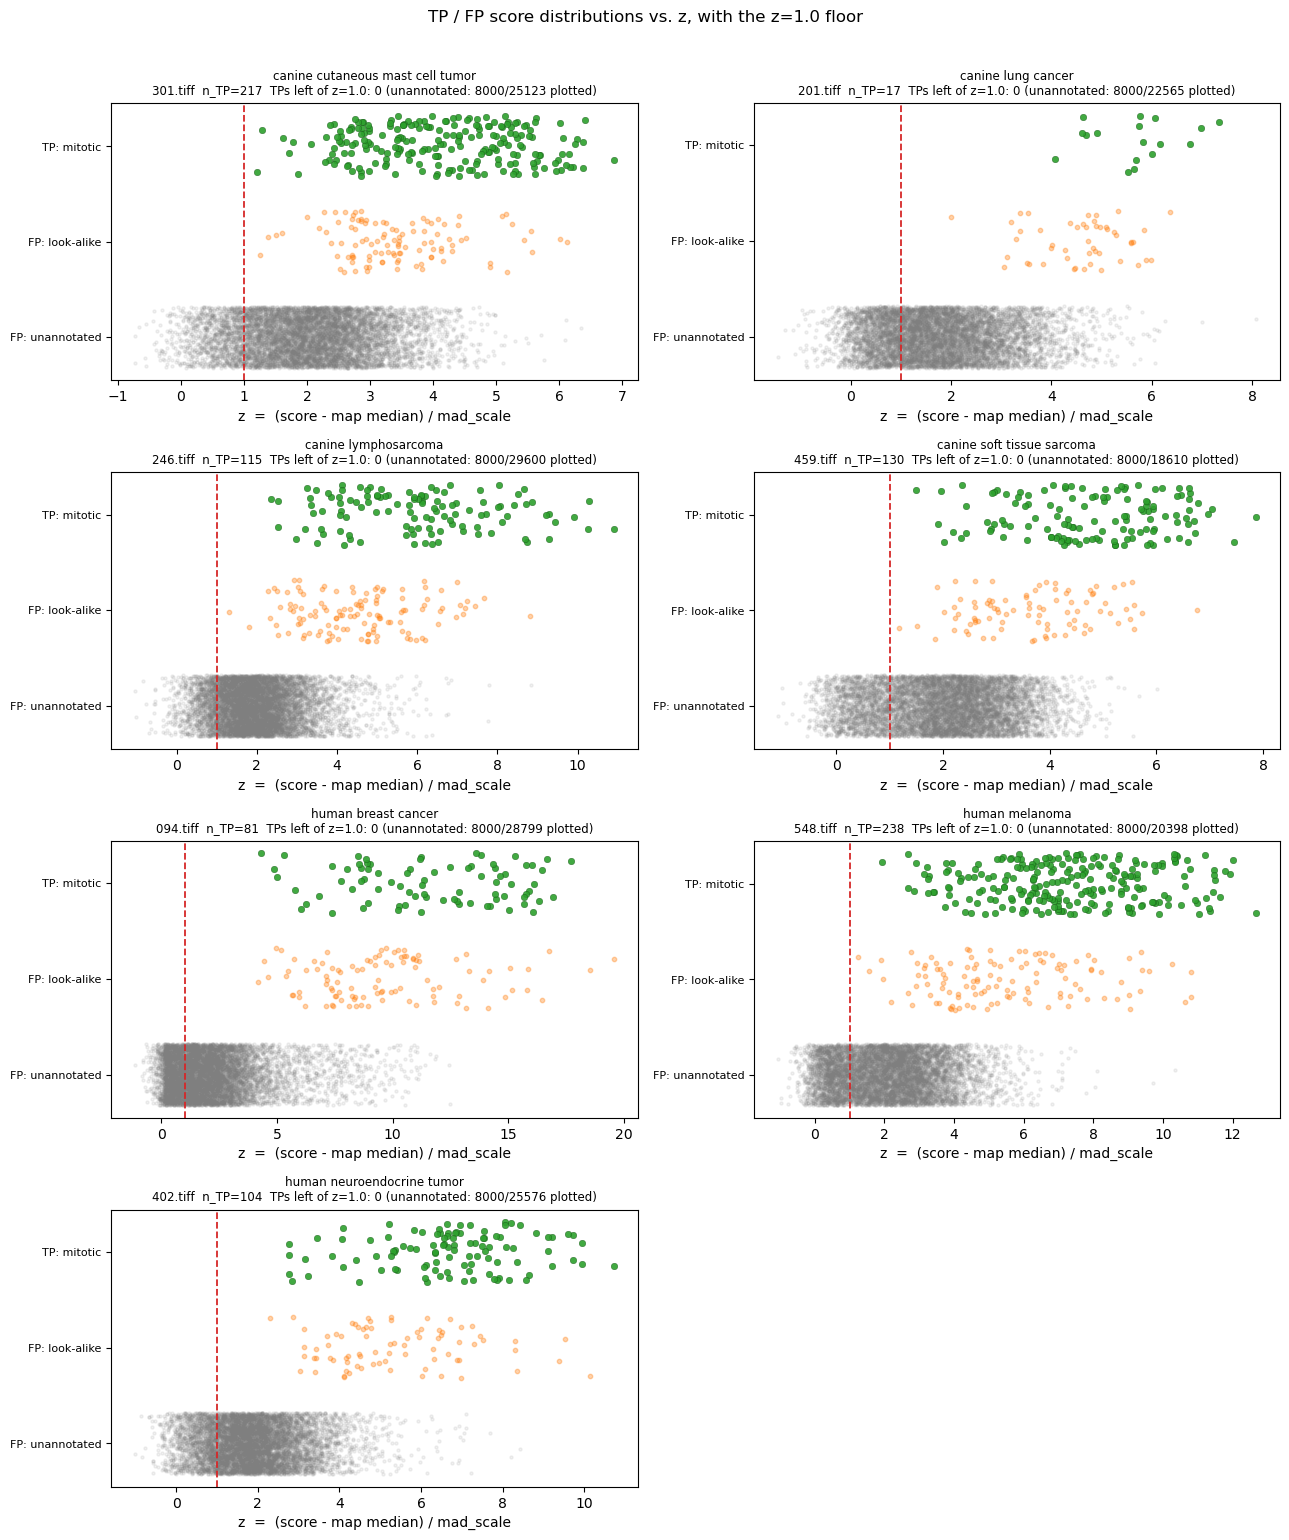

In [6]:
rng = np.random.default_rng(RNG_SEED)
domains_by_file = domain_images.set_index('file_name')['tumor_type'].to_dict()
files = list(domain_images.sort_values('tumor_type')['file_name'])
n = len(files)
ncols = 2
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.8 * nrows))
axes = np.atleast_1d(axes).ravel()

JITTER = 0.32
STYLE = {
    ev.NON_HUMAN_FINDINGS: dict(s=5, alpha=0.10, zorder=1),
    ev.HUMAN_REJECTED_LABEL: dict(s=10, alpha=0.35, zorder=2),
    ev.HUMAN_CORRECT_LABEL: dict(s=22, alpha=0.9, zorder=3, edgecolors='#145214', linewidths=0.3),
}

for ax, fn in zip(axes, files):
    domain = domains_by_file[fn]
    det_out = pools[fn]
    n_sub_note = []
    for bucket in (ev.NON_HUMAN_FINDINGS, ev.HUMAN_REJECTED_LABEL, ev.HUMAN_CORRECT_LABEL):
        sub = det_out[det_out['bucket'] == bucket]
        if bucket == ev.NON_HUMAN_FINDINGS and len(sub) > FP_SUBSAMPLE_CAP:
            idx = rng.choice(len(sub), size=FP_SUBSAMPLE_CAP, replace=False)
            sub = sub.iloc[idx]
            n_sub_note.append(f"unannotated: {FP_SUBSAMPLE_CAP}/{len(det_out[det_out['bucket']==bucket])} plotted")
        lane = BUCKET_LANE[bucket]
        y = lane + rng.uniform(-JITTER, JITTER, size=len(sub))
        st = STYLE[bucket]
        ax.scatter(sub['z'], y, color=BUCKET_COLOR[bucket], **st)

    ax.axvline(CURRENT_Z, color='#d62728', linestyle='--', linewidth=1.3)
    n_tp = int((det_out['bucket'] == ev.HUMAN_CORRECT_LABEL).sum())
    n_tp_cut = int(((det_out['bucket'] == ev.HUMAN_CORRECT_LABEL) & (det_out['z'] < CURRENT_Z)).sum())
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['FP: unannotated', 'FP: look-alike', 'TP: mitotic'], fontsize=8)
    ax.set_xlabel('z  =  (score - map median) / mad_scale')
    note = f" ({'; '.join(n_sub_note)})" if n_sub_note else ''
    ax.set_title(f"{domain}\n{fn}  n_TP={n_tp}  TPs left of z=1.0: {n_tp_cut}{note}", fontsize=8.5)

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle('TP / FP score distributions vs. z, with the z=1.0 floor', y=1.01, fontsize=12)
fig.tight_layout()
plt.show()

## How much does the FP tail overlap the TP range?

The plot shows *where* the classes sit; this quantifies it. For each domain: the TP score
range (in `z`), and what fraction of `non_human_findings` (the class actually driving
candidate volume) sits at or above the lowest TP -- i.e., how much of the FP mass cannot be
separated from TPs by raising `z` any further, because doing so would start cutting TPs
first or simultaneously.

In [7]:
overlap_rows = []
for fn in files:
    det_out = pools[fn]
    tp = det_out[det_out['bucket'] == ev.HUMAN_CORRECT_LABEL]
    fpu = det_out[det_out['bucket'] == ev.NON_HUMAN_FINDINGS]
    if len(tp) == 0:
        continue
    tp_min, tp_max = float(tp['z'].min()), float(tp['z'].max())
    overlap_rows.append({
        'tumor_type': domains_by_file[fn], 'file_name': fn,
        'n_tp': len(tp), 'tp_z_min': round(tp_min, 3), 'tp_z_median': round(float(tp['z'].median()), 3),
        'tp_z_max': round(tp_max, 3),
        'n_fp_unannotated': len(fpu),
        'fp_unannotated_at_or_above_tp_min': int((fpu['z'] >= tp_min).sum()),
        'frac_fp_unannotated_in_tp_range': round(float((fpu['z'] >= tp_min).mean()), 4),
    })
overlap_table = pd.DataFrame(overlap_rows).sort_values('tumor_type')
overlap_table

,tumor_type,file_name,n_tp,tp_z_min,tp_z_median,tp_z_max,n_fp_unannotated,fp_unannotated_at_or_above_tp_min,frac_fp_unannotated_in_tp_range
0,canine cutaneous mast cell tumor,301.tiff,217,1.208,4.112,6.863,25123,20143,0.8018
1,canine lung cancer,201.tiff,17,4.076,5.746,7.352,22565,613,0.0272
2,canine lymphosarcoma,246.tiff,115,2.356,6.010,10.895,29600,8879,0.3000
3,canine soft tissue sarcoma,459.tiff,130,1.498,4.851,7.867,18610,12821,0.6889
4,human breast cancer,094.tiff,81,4.319,11.375,17.699,28799,3001,0.1042
5,human melanoma,548.tiff,238,1.930,7.117,12.672,20398,10775,0.5282
6,human neuroendocrine tumor,402.tiff,104,2.753,6.741,10.721,25576,4637,0.1813


## Reading this

No domain has a true positive below `z = 1.0` (confirmed both by the check-the-work cell
above and directly in every panel: nothing green sits left of the red line), so the current
floor is not the thing cutting TPs -- it's costing nothing yet, and the earlier sweep already
showed recall only starts dropping past `z ~ 1.5`. The overlap table is the actual limit on
pushing further: in every domain a large share of the unannotated-FP mass sits at or above
the *lowest*-scoring TP, so there is no `z` above `1.0` that meaningfully thins the candidate
list without eventually competing with real TPs for the same score range -- the two
distributions are not cleanly separable by `TM_CCOEFF` score alone. That is the concrete
version of the point `chromatin_od` re-ranking exists to address in
`tm_threshold_axis_sweep.ipynb`/`tm_threshold_axis_sweep_v2.ipynb`: since the search score
cannot separate these two populations much further, cutting candidate *count* without
cutting recall needs a second, largely-independent signal to rank by -- not a stricter cut on
the same one.